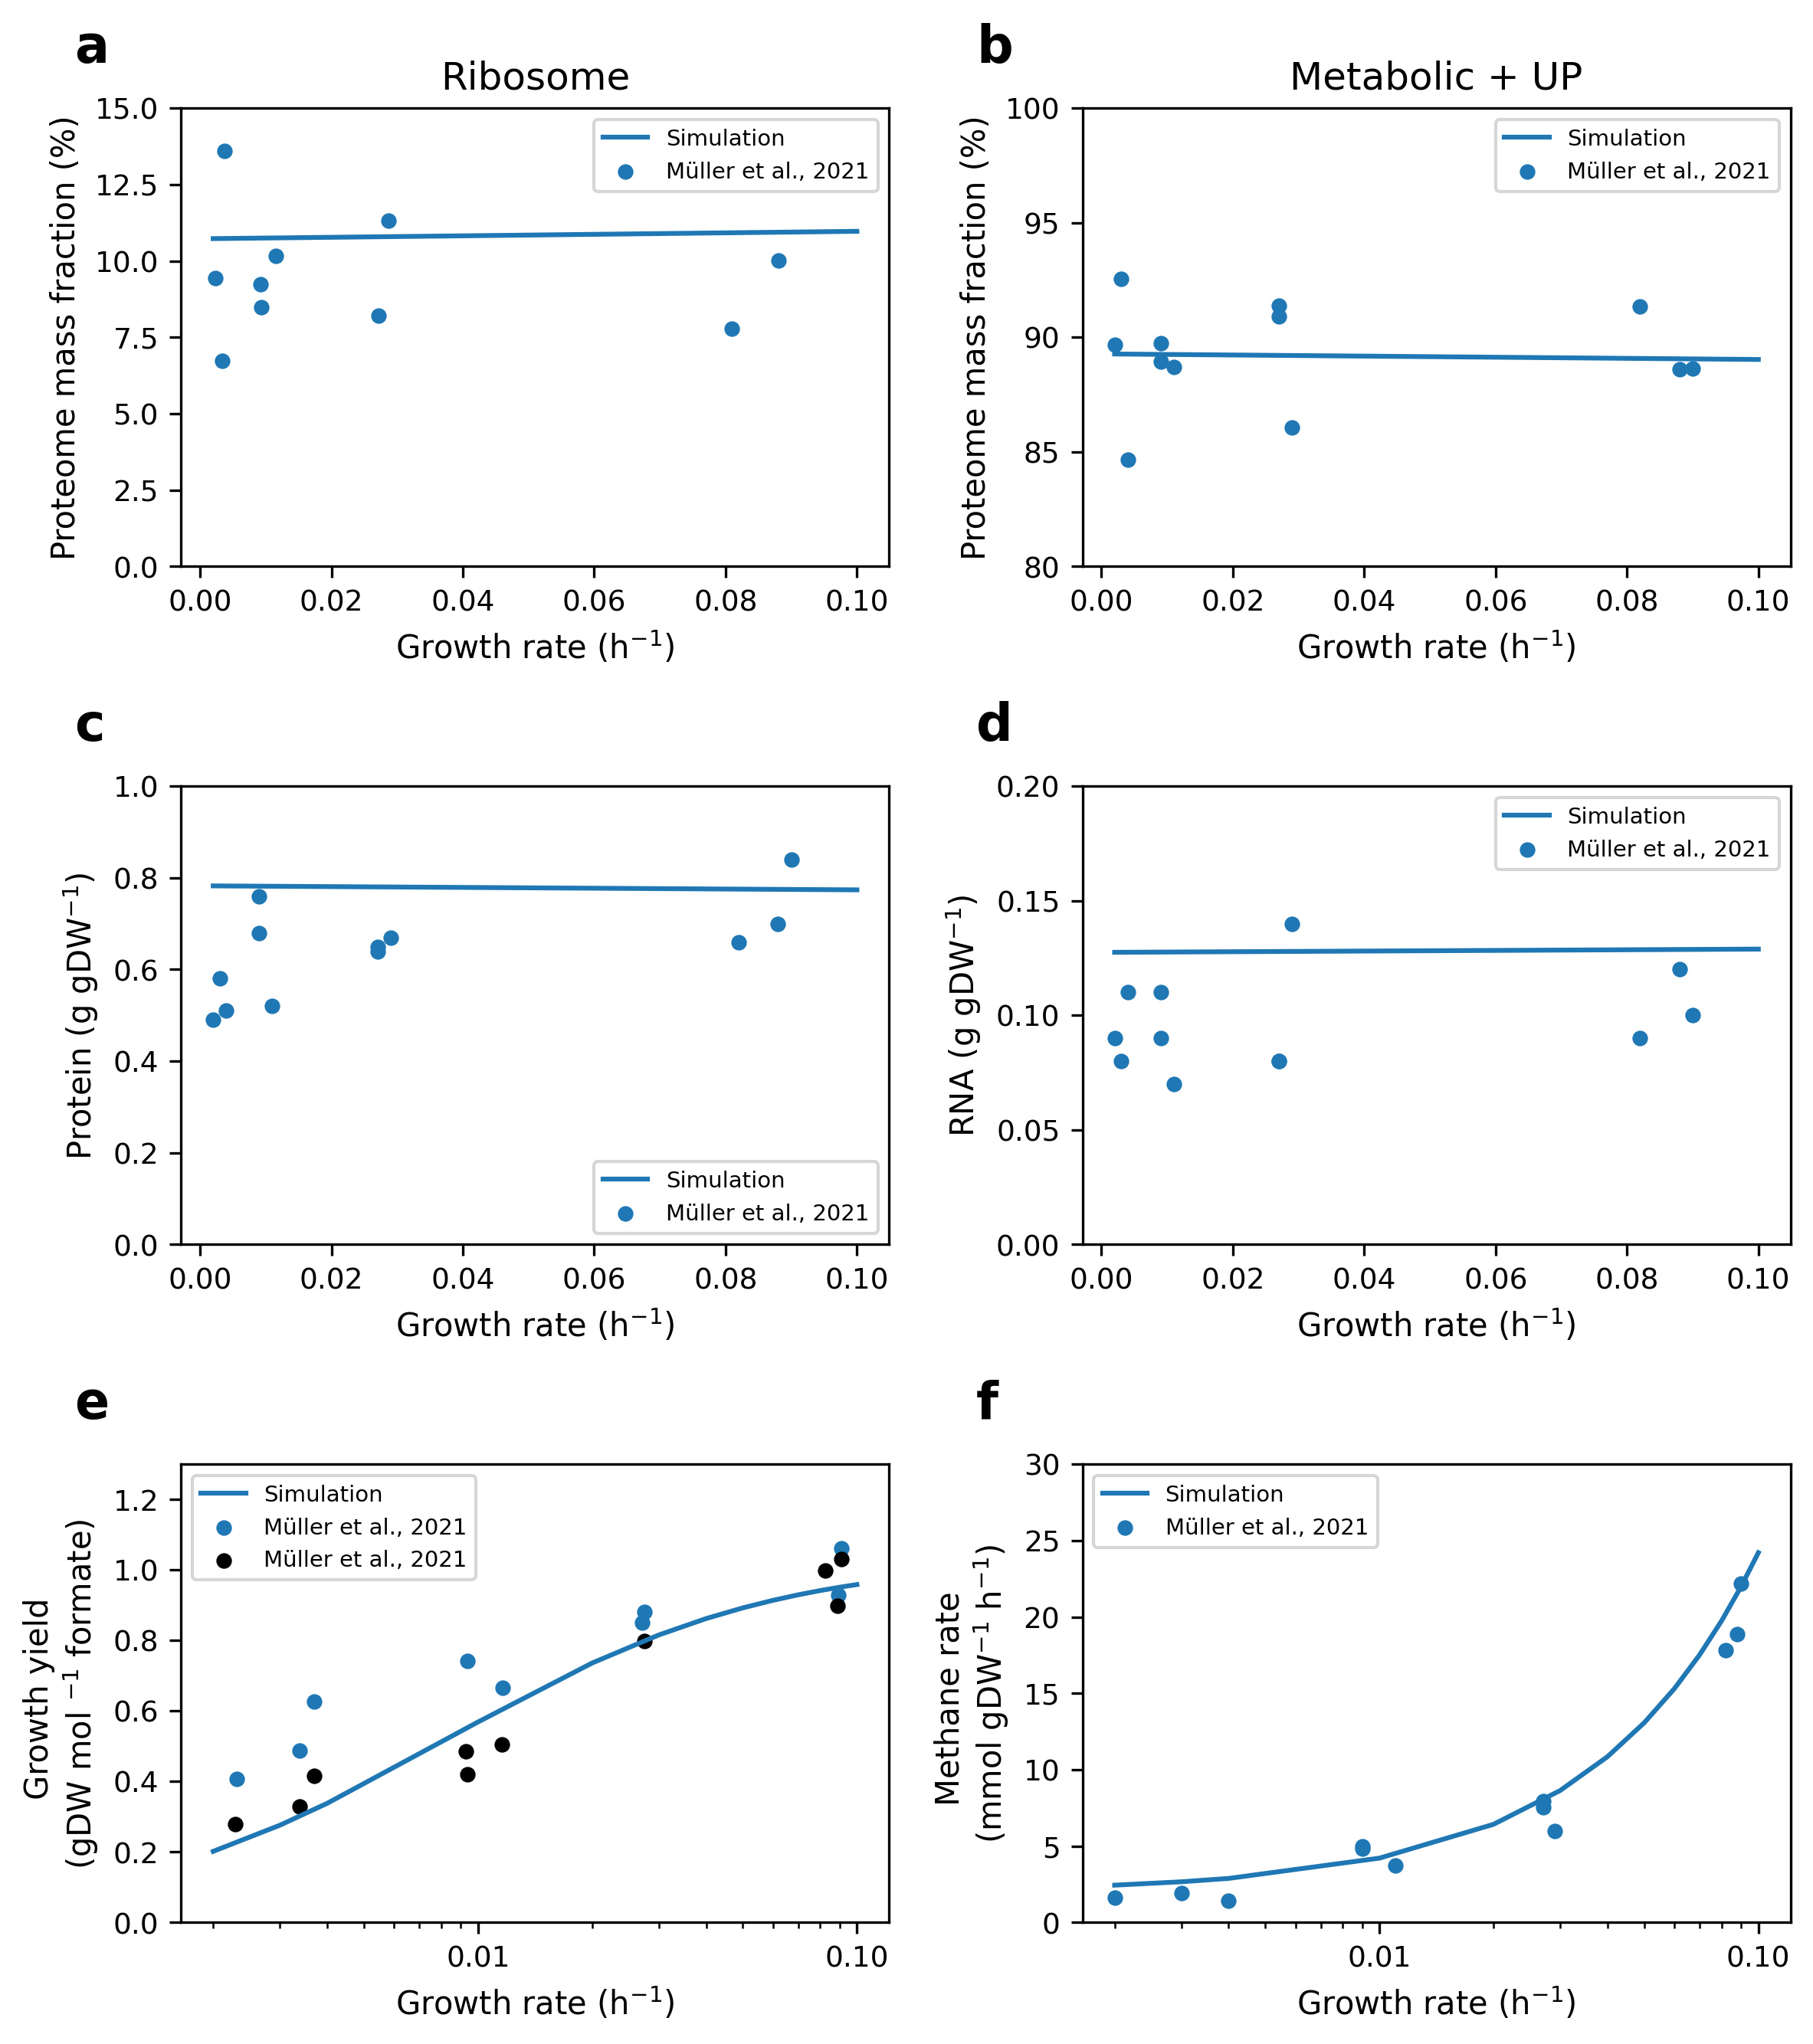

In [1]:
from simulation import Simulation
from extract_fluxes import Fluxes
import matplotlib.pyplot as plt
import  numpy as np
import pandas as pd
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
def limitation_simulation():
    total_protein_mass=0.6
    up_formate_ratio=0.75*total_protein_mass
    methane_id,formate_id = "R944","R895"
    # closed import H2 ,CO2 , CO ,Aceteta
    closed_reactions = ["R946", "R913", "R1165", "R983"]
    sim = Simulation()
    # objective is formate 
    sim.set_parameter(model_file='pcMMP.xml', objective="R895", GAM=25, NGAM=1, excel_file='pcMMP.xlsx')
    sim.set_constraint = [f"UP >= {up_formate_ratio}","Glycogen=0.02"]
    sim.close_reactions(closed_reactions)
    results = {
        "mu_list": [], "methane_list": [], "formate_list": [], "rna_list": [],
         "glycogen_list": [], "metabolic_up_list": [], "methanogenesis_list": [],
        "ribosome_list": [], "total_proteins": [], "atp_list": []
    }
    mus=[0.002,0.003,0.004, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1]
    for i, mu in enumerate(mus, start=1):
        sim.file_path = f"output/lp_file_limited_{i}.lp"
        sim.output_file = f"output/output_limited_{i}.lp"
        if sim.check_mu_optimal(mu):
            fluxes = Fluxes(sim.model, f'output/output_limited_{i}.lp')
            results["mu_list"].append(mu)
            results["methane_list"].append(fluxes.extract_reaction_flux(methane_id))
            results["formate_list"].append(fluxes.extract_reaction_flux(formate_id))
            results["rna_list"].append(fluxes.extract_reaction_flux("RNA"))
            results["glycogen_list"].append(fluxes.extract_reaction_flux("Glycogen"))
            total_protein = fluxes.extract_reaction_flux("total_protein")
            up = fluxes.extract_reaction_flux("UP")
            results["metabolic_up_list"].append(((up + fluxes.extract_reaction_flux("metaboicMass")) / total_protein)*100)
            results["ribosome_list"].append((fluxes.extract_reaction_flux("ribosome_mass") / total_protein)*100)
            results["total_proteins"].append(total_protein)
          
            
        else:
            print(f"mu={mu} is not optimal")

    return results


def calculate_growth_yield(mu_list, formate_list):
    growth_yield=[]
    for i in range(len(formate_list)):
        value = (mu_list[i]/formate_list[i])*1000
        growth_yield.append(value)
    return growth_yield

def plot(results_formate):
    plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize":9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7
    })

    mu_list = results_formate['mu_list']

     # exp_data : experiment data from Müller et al., 2021
  
    ribosome_formate_growth_rate= [0.003378591, 0.002283602, 0.003677198, 0.009335012, 0.009236709, 0.011536363, 0.080918156, 0.088069874, 0.027194596, 0.028672867]
    ribosome_proteome_formate= [6.737044289, 9.443378583, 13.58925051, 8.493282875, 9.241842863, 10.16314822, 7.773513233, 10.0191943, 8.205375018, 11.31477965]
    metabolic_up_formate_growth_rate=[0.003,0.002,0.004,0.009,0.009,0.011,0.027,0.027,0.029,0.090,0.082,0.088]
    metabolic_up_proteome_formate=[92.53326444,89.68149127,84.6638401,89.73814579,88.94636537,88.69243964,90.8952381,91.36403345,86.06815203,88.63525391,91.35786802,88.60987625]
    protein_formate_growth_rate=[0.003,0.002,0.004,0.009,0.009,0.011,0.027,0.027,0.029,0.090,0.082,0.088]
    protein_formate=[0.58,0.49,0.51,0.76,0.68,0.52,0.65,0.64,0.67,0.84,0.66,0.70]
    rna_formate_growth_rate=[0.003,0.002,0.004,0.009,0.009,0.011,0.027,0.027,0.029,0.090,0.082,0.088]
    rna_formate=[0.08,0.09,0.11,0.09,0.11,0.07,0.08,0.08,0.14,0.10,0.09,0.12]

    growth_yeild_formate_x_1=[0.002308457,0.003383855,0.003693805,0.009382496,0.011634396,0.027072337,0.027507195,0.090881836,0.089445148]
    growth_yeild_formate_y_1=[0.406626516,0.488382089,0.626075746,0.742254774,0.664802061,0.849827918,0.87994839,1.060671263,0.929431937]
    growth_yeild_formate_x_2=[0.002290138,0.003383855,0.003693805,0.009382496,0.009308034,0.01154207,0.027507195,0.088735397,0.090881836,0.082595182]
    growth_yeild_formate_y_2=[0.279690256,0.329173885,0.4152324,0.419535343,0.486230659,0.505593858,0.798192776,0.899311547,1.03055075,0.998278848]

    growth_rate_methane_formate= [0.003,0.002,0.004,0.009,0.009,0.011,0.027,0.027,0.029,0.090,0.082,0.088]
    methane_formate= [1.90,1.63,1.41,4.82,4.97,3.72,7.54,7.96,5.98,22.19,17.84,18.86]

  
    fig, axes = plt.subplots(3, 2, figsize=(8, 9), dpi=300)  
    subplot_labels = ["a", "b", "c", "d", "e", "f"]

    # --- Ribosome ---
    axes[0, 0].plot(mu_list, results_formate['ribosome_list'], label="Simulation", color='#1f77b4')
    axes[0, 0].scatter(ribosome_formate_growth_rate, ribosome_proteome_formate,  s=15, label="Müller et al., 2021", color='#1f77b4')
    axes[0, 0].set_title("Ribosome")
    axes[0, 0].set_ylabel("Proteome mass fraction (%)")
    axes[0, 0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 15)
    axes[0, 0].text(-0.15, 1.1, subplot_labels[0], transform=axes[0, 0].transAxes, fontsize=16, fontweight='bold')

    # --- Metabolic + UP ---
    axes[0, 1].plot(mu_list, results_formate['metabolic_up_list'], label="Simulation", color='#1f77b4')
    axes[0, 1].scatter(metabolic_up_formate_growth_rate, metabolic_up_proteome_formate,  s=15, label="Müller et al., 2021", color='#1f77b4')
    axes[0, 1].set_title("Metabolic + UP")
    axes[0, 1].set_ylabel("Proteome mass fraction (%)")
    axes[0, 1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0, 1].legend()
    axes[0, 1].set_ylim(80, 100)
    axes[0, 1].text(-0.15, 1.1, subplot_labels[1], transform=axes[0, 1].transAxes, fontsize=16, fontweight='bold')

    # --- Protein ---
    axes[1, 0].plot(mu_list, results_formate['total_proteins'], label="Simulation",color='#1f77b4')
    axes[1, 0].scatter(protein_formate_growth_rate, protein_formate,  s=15, label="Müller et al., 2021", color='#1f77b4')
    axes[1, 0].set_ylabel("Protein (g gDW$^{-1}$)")
    axes[1, 0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1, 0].legend(loc="lower right")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].text(-0.15, 1.1, subplot_labels[2], transform=axes[1, 0].transAxes, fontsize=16, fontweight='bold')

    # --- RNA ---
    axes[1, 1].plot(mu_list, results_formate['rna_list'], label="Simulation", color='#1f77b4')
    axes[1, 1].scatter(rna_formate_growth_rate, rna_formate,  s=15, label="Müller et al., 2021", color='#1f77b4')
    axes[1, 1].set_ylabel("RNA (g gDW$^{-1}$)")
    axes[1, 1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1, 1].legend()
    axes[1, 1].set_ylim(0, 0.2)
    axes[1, 1].text(-0.15, 1.1, subplot_labels[3], transform=axes[1, 1].transAxes, fontsize=16, fontweight='bold')

    # --- Growth yield  ---
    growth_yield_formate=calculate_growth_yield(mu_list, results_formate["formate_list"])
  
    axes[2, 0].plot(mu_list, growth_yield_formate, label="Simulation", color='#1f77b4')
    axes[2, 0].scatter(growth_yeild_formate_x_1, growth_yeild_formate_y_1,  s=15, label="Müller et al., 2021", color='#1f77b4')
    axes[2, 0].scatter(growth_yeild_formate_x_2, growth_yeild_formate_y_2,  s=15, label="Müller et al., 2021", color='black')
    axes[2, 0].set_ylabel("Growth yield \n(gDW mol $^{-1}$ formate)")
    axes[2, 0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[2, 0].legend(loc="upper left")
    axes[2, 0].set_xscale('log')
    axes[2, 0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[2, 0].set_ylim(0,1.3)
    axes[2, 0].text(-0.15, 1.1, subplot_labels[4], transform=axes[2, 0].transAxes, fontsize=16, fontweight='bold')

    # --- methane ----
    axes[2, 1].plot(mu_list, results_formate['methane_list'], label="Simulation", color='#1f77b4')
    axes[2, 1].scatter(growth_rate_methane_formate, methane_formate,  s=15, label="Müller et al., 2021", color='#1f77b4')
    axes[2, 1].set_ylabel("Methane rate \n(mmol gDW$^{-1}$ h$^{-1}$)")
    axes[2, 1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[2, 1].legend(loc="upper left")
    axes[2, 1].set_ylim(0, 30)
    axes[2, 1].set_xscale('log')
    axes[2, 1].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[2, 1].text(-0.15, 1.1, subplot_labels[5], transform=axes[2, 1].transAxes, fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.savefig("Figures/Formate_constrained_glycogen.png", dpi=300)
    plt.show()
if __name__ == "__main__":
    results_formate = limitation_simulation()
    plot(results_formate)
    
    